In [5]:
# ── Cell 1: Install & verify GPU ──────────────────────────────────────────────
# YOLO26 requires ultralytics >= 8.4.0. Roboflow provides the dataset.
!pip install -q "ultralytics>=8.4.0" roboflow supervision

import torch
from ultralytics import YOLO

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 136.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ul

In [6]:
# ── Cell 2: Download Roboflow dataset ─────────────────────────────────────────

from roboflow import Roboflow

rf = Roboflow(api_key="FYU8yfIsWKfp5ZpbHxm4")          # ← paste your key
project = rf.workspace("capstone-nh0nc").project("car-damage-detection-t0g92")
version = project.version(4)
dataset = version.download("yolo26")

DATASET_YAML = dataset.location + "/data.yaml"
print(f"Dataset path : {dataset.location}")
print(f"data.yaml    : {DATASET_YAML}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-Damage-Detection-4 in yolo26:: 100%|██████████| 15530/15530 [00:01<00:00, 10641.46it/s]


Dataset path : /content/Car-Damage-Detection-4
data.yaml    : /content/Car-Damage-Detection-4/data.yaml


In [7]:
import os
import shutil
import yaml
from pathlib import Path
from roboflow import Roboflow

print("1. Downloading Supplemental 'Trunk Additions' Dataset...")
# Your exact snippet
rf = Roboflow(api_key="FYU8yfIsWKfp5ZpbHxm4") # Make sure your real key is here!
project = rf.workspace("alarm-j1oeb").project("trunk-additions")
version = project.version(1)
supp_dataset = version.download("yolo26")

# 2. Define our paths
# `dataset` is your main dataset variable from Cell 2
MAIN_DIR = Path(dataset.location)
SUPP_DIR = Path(supp_dataset.location)

print("\n2. Analyzing Class ID Structures...")
with open(MAIN_DIR / "data.yaml", 'r') as f:
    main_yaml = yaml.safe_load(f)
with open(SUPP_DIR / "data.yaml", 'r') as f:
    supp_yaml = yaml.safe_load(f)

main_classes = main_yaml['names']
supp_classes = supp_yaml['names']

print(f"   Main Classes: {main_classes}")
print(f"   Supp Classes: {supp_classes}")

# 3. Create the Translation Dictionary mapping Supp IDs to Main IDs
id_translation_map = {}
for supp_id, supp_name in enumerate(supp_classes):
    # Ensure capitalization matches exactly (e.g., 'Dickey' vs 'dickey')
    match = [main_id for main_id, main_name in enumerate(main_classes) if main_name.lower() == supp_name.lower()]

    if match:
        main_id = match[0]
        id_translation_map[supp_id] = main_id
        print(f"   Mapped '{supp_name}': Supp ID {supp_id} -> Main ID {main_id}")
    else:
        print(f"   ❌ ERROR: Class '{supp_name}' from supplement not found in main dataset!")

# 4. The Merge Function
def merge_and_translate(split_name):
    supp_img_dir = SUPP_DIR / split_name / 'images'
    supp_lbl_dir = SUPP_DIR / split_name / 'labels'
    main_img_dir = MAIN_DIR / split_name / 'images'
    main_lbl_dir = MAIN_DIR / split_name / 'labels'

    if not supp_img_dir.exists():
        return 0

    copied_count = 0
    for img_path in supp_img_dir.glob('*'):
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.webp']:
            continue

        # A. Copy the Image
        shutil.copy(img_path, main_img_dir / img_path.name)

        # B. Read, Translate, and Copy the Label
        lbl_path = supp_lbl_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            new_lines = []
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        old_id = int(parts[0])
                        if old_id in id_translation_map:
                            new_id = id_translation_map[old_id]
                            parts[0] = str(new_id) # Replace with the correct Main ID
                            new_lines.append(" ".join(parts) + "\n")

            # Write the translated label to the Main dataset
            with open(main_lbl_dir / lbl_path.name, 'w') as f:
                f.writelines(new_lines)

        copied_count += 1
    return copied_count

print("\n3. Merging and Translating Labels...")
total_added = 0
for split in ['train', 'valid', 'test']: # Roboflow often uses 'valid' instead of 'val'
    added = merge_and_translate(split)
    total_added += added
    print(f"   Merged {added} images into {split.upper()} split.")

print(f"\n✅ SUCCESS! Injected {total_added} heavily-augmented trunk images into the main dataset.")
print("You are ready to run Cell 3 (Sanity Check) and Cell 4 (Train)!")

1. Downloading Supplemental 'Trunk Additions' Dataset...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Trunk-Additions-1 in yolo26:: 100%|██████████| 159/159 [00:00<00:00, 5086.25it/s]


2. Analyzing Class ID Structures...
   Main Classes: ['Bonnet', 'Bumper', 'Dickey', 'Door', 'Fender', 'Light', 'Windshield']
   Supp Classes: ['Bumper', 'Dickey', 'Light']
   Mapped 'Bumper': Supp ID 0 -> Main ID 1
   Mapped 'Dickey': Supp ID 1 -> Main ID 2
   Mapped 'Light': Supp ID 2 -> Main ID 5

3. Merging and Translating Labels...
   Merged 78 images into TRAIN split.
   Merged 0 images into VALID split.
   Merged 0 images into TEST split.

✅ SUCCESS! Injected 78 heavily-augmented trunk images into the main dataset.
You are ready to run Cell 3 (Sanity Check) and Cell 4 (Train)!


Classes: ['Bonnet', 'Bumper', 'Dickey', 'Door', 'Fender', 'Light', 'Windshield']
nc     : 7

Label distribution (train):
  [0] Bonnet                    →  1035 instances
  [1] Bumper                    →  3695 instances
  [2] Dickey                    →   540 instances
  [3] Door                      →  1797 instances
  [4] Fender                    →  2243 instances
  [5] Light                     →  1557 instances
  [6] Windshield                →   888 instances


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


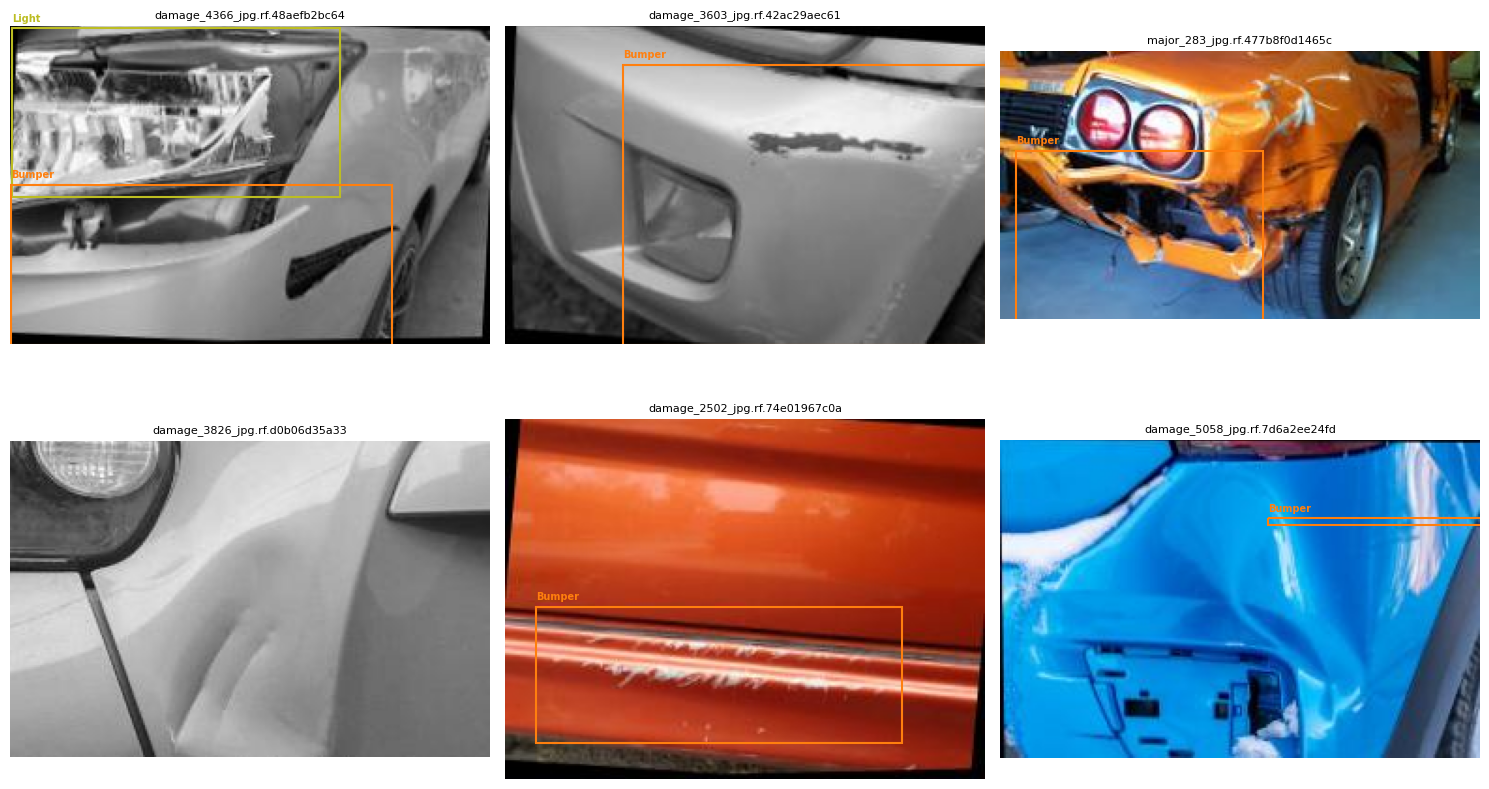

Saved → sample_annotations.png


In [8]:
# ── Cell 3: Sanity-check the dataset before training ──────────────────────────
import yaml, os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random, textwrap

with open(DATASET_YAML) as f:
    meta = yaml.safe_load(f)

print("Classes:", meta["names"])
print("nc     :", meta["nc"])

# Count labels per class across the train split
label_dir = Path(dataset.location) / "train" / "labels"
class_counts = Counter()
for lf in label_dir.glob("*.txt"):
    for line in lf.read_text().splitlines():
        if line.strip():
            class_counts[int(line.split()[0])] += 1

print("\nLabel distribution (train):")
for idx, name in enumerate(meta["names"]):
    print(f"  [{idx}] {name:25s} → {class_counts[idx]:5d} instances")

#  Visualise
img_dir   = Path(dataset.location) / "train" / "images"
img_files = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
sample    = random.sample(img_files, min(6, len(img_files)))
COLORS    = plt.cm.get_cmap("tab10", meta["nc"])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flat, sample):
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img)
    lbl_path = label_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            parts = list(map(float, line.split()))
            cls_id = int(parts[0])
            cx, cy, bw, bh = parts[1], parts[2], parts[3], parts[4]
            x1 = (cx - bw / 2) * W;  y1 = (cy - bh / 2) * H
            rect = patches.Rectangle((x1, y1), bw*W, bh*H,
                                      linewidth=1.5, edgecolor=COLORS(cls_id),
                                      facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, meta["names"][cls_id],
                    color=COLORS(cls_id), fontsize=7, fontweight="bold")
    ax.axis("off")
    ax.set_title(img_path.name[:30], fontsize=8)
plt.tight_layout()
plt.savefig("sample_annotations.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → sample_annotations.png")

In [9]:
# ── Cell 3.5: Inject Hard Negatives (Reflections & Glare) ─────────────────────
import os
import shutil
import random
from google.colab import drive

print("Mounting Google Drive to access hard negative images...")
drive.mount('/content/drive')

# --- CONFIGURATION ---
# Change this if your Drive folder has a different name
source_dir = '/content/drive/MyDrive/hard_negatives'

# Dynamically using the dataset path defined in Cell 2!
dataset_base = dataset.location
train_img_dir = os.path.join(dataset_base, 'train', 'images')
train_lbl_dir = os.path.join(dataset_base, 'train', 'labels')
val_img_dir = os.path.join(dataset_base, 'valid', 'images')
val_lbl_dir = os.path.join(dataset_base, 'valid', 'labels')

# --- PROCESSING ---
print(f"Scanning for images in: {source_dir}")
all_images = [f for f in os.listdir(source_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random.shuffle(all_images)

# 80/20 Split
split_idx = int(len(all_images) * 0.8)
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

print(f"Found {len(all_images)} background images.")
print(f"Injecting {len(train_images)} to Train, {len(val_images)} to Valid.")

# Helper function
def inject_data(image_list, target_img_dir, target_lbl_dir):
    for img_name in image_list:
        src_img_path = os.path.join(source_dir, img_name)
        dst_img_path = os.path.join(target_img_dir, img_name)

        # Define empty label path
        label_name = os.path.splitext(img_name)[0] + '.txt'
        dst_lbl_path = os.path.join(target_lbl_dir, label_name)

        # Copy image and create empty label
        shutil.copy(src_img_path, dst_img_path)
        with open(dst_lbl_path, 'w') as f:
            pass

# Execute
inject_data(train_images, train_img_dir, train_lbl_dir)
inject_data(val_images, val_img_dir, val_lbl_dir)

print("✅ Injection Complete! Empty labels generated and merged seamlessly.")

Mounting Google Drive to access hard negative images...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scanning for images in: /content/drive/MyDrive/hard_negatives
Found 370 background images.
Injecting 296 to Train, 74 to Valid.
✅ Injection Complete! Empty labels generated and merged seamlessly.


In [8]:
# ── Cell 4: Train YOLO26-Small (T4-safe) ──────────────────────────────────────

from ultralytics import YOLO
from pathlib import Path

model = YOLO("yolo26s.pt")

results = model.train(
    data             = DATASET_YAML,
    epochs           = 60,
    patience         = 15,
    imgsz            = 640,
    batch            = 8,
    optimizer        = "auto",
    lr0              = 0.005,
    lrf              = 0.01,
    momentum         = 0.937,
    weight_decay     = 0.0005,
    warmup_epochs    = 3,
    warmup_momentum  = 0.8,
    cos_lr           = True,

    box              = 7.5,
    cls              = 0.7,
    # Augmentation
    hsv_h            = 0.015,
    hsv_s            = 0.9,
    hsv_v            = 0.6,
    degrees          = 15.0,
    translate        = 0.1,
    scale            = 0.6,
    flipud           = 0.01,
    fliplr           = 0.5,
    mosaic           = 1.0,
    close_mosaic     = 20,
    copy_paste       = 0.15,
    mixup            = 0.1,
    # Performance
    multi_scale      = False,
    amp              = True,
    cache            = "disk",
    workers          = 2,
    device           = 0,
    project          = "car_damage_model1",
    name             = "yolo26s_damage_type",
    exist_ok         = True,
    plots            = True,
    save_period      = 5,
    verbose          = True,
)

BEST_WEIGHTS = str(Path(results.save_dir) / "weights" / "best.pt")
print(f"\nBest weights → {BEST_WEIGHTS}")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=20, cls=0.7, cls_pw=0.0, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Car-Damage-Detection-4/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.01, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.9, hsv_v=0.6, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo26s_damage_type, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [9]:
# ── Cell 4.5: Backup Weights
import os
import shutil
from google.colab import drive
from pathlib import Path


drive_backup_folder = '/content/drive/MyDrive/CDD-70epoch'
os.makedirs(drive_backup_folder, exist_ok=True)


try:
    source_weights = Path(results.save_dir) / "weights" / "best.pt"
    print(f"Located weights at: {source_weights}")
except NameError:
    # Fallback just in case the 'results' variable was cleared from memory
    fallback_path = "/content/runs/detect/car_damage_model1/yolo26s_damage_type/weights/best.pt"
    source_weights = Path(fallback_path)
    print(f"Using fallback path: {source_weights}")

# 4. Copy the file to Google Drive
if source_weights.exists():
    # You can rename the file here to keep track of your different experiments
    destination_file = os.path.join(drive_backup_folder, "yolo26s_glare_resistant_best.pt")

    print("Copying to Google Drive... Please wait.")
    shutil.copy(str(source_weights), destination_file)
    print(f"SUCCESS! Your model is safely backed up to:\n{destination_file}")
else:
    print(f"ERROR: Could not find the trained weights.")
    print(f"Checked path: {source_weights}")
    print("Ensure Cell 4 actually finished training and generated a 'best.pt' file.")

Located weights at: /content/runs/detect/car_damage_model1/yolo26s_damage_type/weights/best.pt
Copying to Google Drive... Please wait.
✅ SUCCESS! Your model is safely backed up to:
/content/drive/MyDrive/CDD-70epoch/yolo26s_glare_resistant_best.pt


In [10]:
from google.colab import files
import os

source_weights = "/content/runs/detect/car_damage_model1/yolo26s_damage_type/weights/best.pt"

if os.path.exists(source_weights):
    print("Triggering browser download...")
    files.download(source_weights)

Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ── Cell 5: View training curves & resume if needed ───────────────────────────
from IPython.display import display, Image as IPyImage
from pathlib import Path
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

run_dir = Path(results.save_dir)
print(f"Run directory: {run_dir}")
print(f"Contents:")
for f in sorted(run_dir.iterdir()):
    print(f"  {f.name}")

# ── Collect all PNG plots generated by Ultralytics ───────────────────────────
plots = sorted(run_dir.glob("*.png"))
print(f"\nFound {len(plots)} diagnostic plots:")
for p in plots:
    print(f"  {p.name}")

if len(plots) == 0:

    weights_dir = run_dir / "weights"
    if weights_dir.exists():
        print("\n⚠  Plots not yet generated — training is likely still in early epochs.")
        print("   Plots are written at the END of training (or per save_period).")
        print("   Re-run this cell after training completes.")
    else:
        print("\n⚠  Run directory looks empty. Check that Cell 4 completed successfully.")
else:
    # Render each plot inline
    for p in plots:
        print(f"\n── {p.name} ──")
        img = PILImage.open(p)
        w, h = img.size

        display_w = min(900, w)
        display_h = int(h * display_w / w)
        display(img.resize((display_w, display_h)))

results_csv = run_dir / "results.csv"
if results_csv.exists():
    import pandas as pd
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()   # Ultralytics adds whitespace to headers
    print(f"\nTraining log: {len(df)} epochs recorded so far")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Training progress (from results.csv)", fontsize=12)

    # Box loss
    axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
    if "val/box_loss" in df.columns:
        axes[0].plot(df["epoch"], df["val/box_loss"], label="val")
    axes[0].set_title("Box loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # Cls loss
    axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
    if "val/cls_loss" in df.columns:
        axes[1].plot(df["epoch"], df["val/cls_loss"], label="val")
    axes[1].set_title("Class loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    # mAP
    if "metrics/mAP50(B)" in df.columns:
        axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
    if "metrics/mAP50-95(B)" in df.columns:
        axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
    axes[2].set_title("mAP")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(run_dir / "manual_curves.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → manual_curves.png")
else:
    print("\nresults.csv not found yet — training has not started or Cell 4 did not complete.")



NameError: name 'results' is not defined

In [ ]:
# ── Cell 6: Validate best checkpoint ─────────────────────────────────────────
from ultralytics import YOLO
from pathlib import Path

print(f"Loading weights from: {BEST_WEIGHTS}")
assert Path(BEST_WEIGHTS).exists(), (
    f"best.pt not found at {BEST_WEIGHTS}\n"
    "Either training hasn't finished, or you need to set BEST_WEIGHTS manually above."
)

model = YOLO(BEST_WEIGHTS)

val_results = model.val(
    data      = DATASET_YAML,
    imgsz     = 640,
    batch     = 16,        # No gradient during val — can push higher than train batch
    device    = 0,
    plots     = True,
    save_json = True,
    split     = "val",
)

# ── Per-class AP50 breakdown ──────────────────────────────────────────────────
print("\n── Per-class AP50 ──────────────────────────────────────────")
for i, name in enumerate(val_results.names.values()):
    ap = (val_results.box.ap50[i]
          if i < len(val_results.box.ap50) else float("nan"))
    bar = "█" * int(ap * 30)
    flag = "  ⚠ LOW" if ap < 0.40 else ""
    print(f"  [{i}] {name:25s}  AP50: {ap:.3f}  {bar}{flag}")

print(f"\n  mAP50     : {val_results.box.map50:.4f}")
print(f"  mAP50-95  : {val_results.box.map:.4f}")
print(f"  Precision : {val_results.box.mp:.4f}")
print(f"  Recall    : {val_results.box.mr:.4f}")

# ── Advice for underperforming classes ────────────────────────────────────────
low = [
    val_results.names[i]
    for i in range(len(val_results.names))
    if i < len(val_results.box.ap50) and val_results.box.ap50[i] < 0.40
]
if low:
    print(f"\n⚠  Classes below AP50=0.40: {low}")
    print("   Recommended actions:")
    print("   1. Increase copy_paste to 0.6 for these classes and retrain.")
    print("   2. Check Cell 3 label distribution — these are likely minority classes.")
    print("   3. Consider collecting 30–50 more images specifically for these classes.")
else:
    print("\n✅ All classes above AP50=0.40 threshold.")

Loading weights from: /content/runs/detect/car_damage_model1/yolo26s_damage_type/weights/best.pt
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,467,889 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 47.8±61.9 MB/s, size: 8.7 KB)
val: Scanning /content/Car-Damage-Detection-4/valid/labels.cache... 910 images, 78 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 910/910 173.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1103, len(boxes) = 1586. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 4.9it/s 11.6s
                   all        910       1586      0.635      0.529      0.541      0.256
                